<a href="https://colab.research.google.com/github/chrishg23-jpg/HES-benchmark/blob/main/HES18Sim006.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import correlate

# Generate a structured void field with correlation length ~ lambda0
def generate_void_state(N=256, lambda0=10, coherence=0.8):
    x = np.arange(N)
    center = N // 2
    sigma = lambda0
    kernel = np.exp(-((x - center)**2) / (2 * sigma**2))
    kernel /= kernel.sum()
    w = np.random.randn(N)
    u_corr = np.real(np.fft.ifft(np.fft.fft(w) * np.fft.fft(kernel)))
    trend = np.exp(-((x - center)**2) / (2 * (2*sigma)**2))
    u_void = coherence * trend + (1 - coherence) * (u_corr / np.std(u_corr))
    return u_void

# Estimate correlation length from autocorrelation
def correlation_length(u_void):
    u = u_void - np.mean(u_void)
    corr = correlate(u, u, mode='full')
    corr = corr[corr.size//2:]
    corr = corr / corr[0]
    thresh = np.exp(-1)
    idxs = np.where(corr[1:] <= thresh)[0]
    if idxs.size == 0:
        idxs = np.where(corr[1:] <= 0.5)[0]
    r_len = (idxs[0] + 1) if idxs.size > 0 else 1
    return r_len, corr

# Toy HES echo field evolution
def evolve_echo(u_void, steps=200, alpha=0.1, beta=0.01, gamma=0.001, dt=0.2, clip=5.0):
    u = u_void.copy()
    for _ in range(steps):
        laplacian = np.roll(u, 1) - 2*u + np.roll(u, -1)
        u = u + dt*(alpha*laplacian - beta*u**3 - gamma*u**5)
        if clip is not None:
            u = np.clip(u, -clip, clip)
    return u


Initial correlation length (≈ λ₀): 29
Final correlation length: 30
Constraint satisfied? True


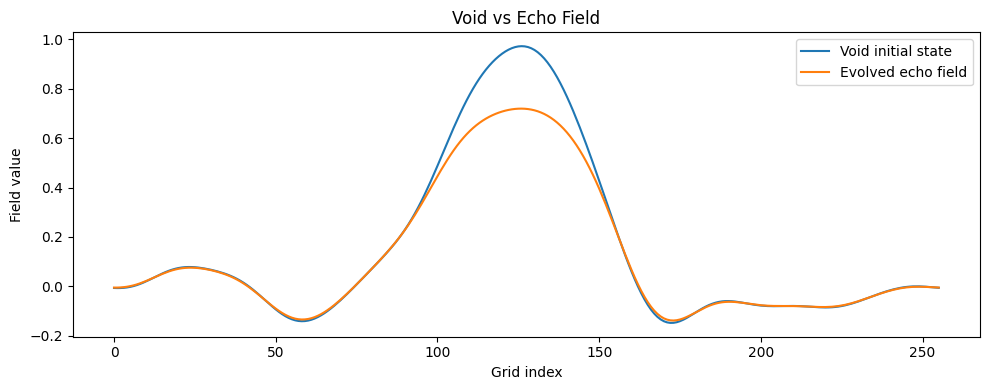

In [6]:
# Parameters
N = 256
lambda0_target = 10
coherence = 0.9
tol = 2

# Generate and evolve
u_void = generate_void_state(N=N, lambda0=lambda0_target, coherence=coherence)
r_init, _ = correlation_length(u_void)
u_evolved = evolve_echo(u_void)
r_final, _ = correlation_length(u_evolved)

# Constraint check
passes = abs(r_final - r_init) < tol

# Output
print("Initial correlation length (≈ λ₀):", r_init)
print("Final correlation length:", r_final)
print("Constraint satisfied?", passes)

# Plot
plt.figure(figsize=(10,4))
plt.plot(u_void, label="Void initial state")
plt.plot(u_evolved, label="Evolved echo field")
plt.legend()
plt.xlabel("Grid index")
plt.ylabel("Field value")
plt.title("Void vs Echo Field")
plt.tight_layout()
plt.show()
